# Label Chip Preparation
This notebook prepares the flower strip label data.
The input data is sourced from INVEKOS dataset, which contains 
agricultural land-use geometries classified by usage codes. Each usage code is collected in one gpkg layer.

The preparation follows these steps:
1. To ensure that all layers are in the same coordinate reference system (CRS), the input layers are reprojected into the working CRS EBSG:3035 (LAEA).
2. Compactness filtering: Some layers contain both compact and linear polygons. 
   Only elongated, linear features are retained using the Polsby-Popper compactness index.
2. Layer fusion: All relevant INVEKOS layers are merged into a single polygon layer.
3. Tree overlay: A tree canopy mask is subtracted from the flower strip polygons to 
   remove areas covered by trees.
4. Polygon filtering: After the overlay, multipart geometries are split into single parts, 
   polygons smaller than 125 m² are removed, and each remaining polygon receives a unique ID.
5. QGIS post-processing: A core-buffer analysis is performed in QGIS to identify and 
   remove geometries with a buffer area ≤ 1.5 m². The final cleaned polygons 
   represent Level 3 (L3) labels used for chip rasterization.

In [1]:
import os
from math import pi
from multiprocessing import Pool
from glob import glob
import numpy as np
import shutil
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
import rasterio
from rasterio.features import shapes
from shapely.geometry import shape
from rasterio.features import rasterize
from rasterio.transform import from_bounds
from shapely.geometry import box


## 1. Reprojection of Layers

In [ ]:
target_crs       = 'EPSG:3035'
input_layer_dir  = '...'

In [ ]:
gpkg_files = [os.path.join(input_layer_dir, f) for f in os.listdir(input_layer_dir) if f.endswith('.gpkg')]

for fp in gpkg_files:
    gdf = gpd.read_file(fp)
    if gdf.crs is None:
        print(f"{os.path.basename(fp)}: WARNING - No CRS defined! Skipping.")
        continue
    epsg = gdf.crs.to_epsg()
    if epsg == 3035:
        print(f"{os.path.basename(fp)}: OK (EPSG:3035)")
    else:
        print(f"{os.path.basename(fp)}: WARNING - EPSG:{epsg} detected, reprojecting to EPSG:3035...")
        gdf = gdf.to_crs("EPSG:3035")
        gdf.to_file(fp, driver='GPKG', OVERWRITE='YES')
        print(f"{os.path.basename(fp)}: Done - reprojected and saved.")

## 2. Compactness

In [ ]:
input_fp          = '.../NRW/NRW_strips90_25.gpkg'
code_column           = 'CODE'
target_code           = 90
compactness_threshold = 0.25

In [ ]:
print(f"dtype der Spalte '{code_column}': {gdf[code_column].dtype}")

Original feature count: 1493
Code feature count: 1493


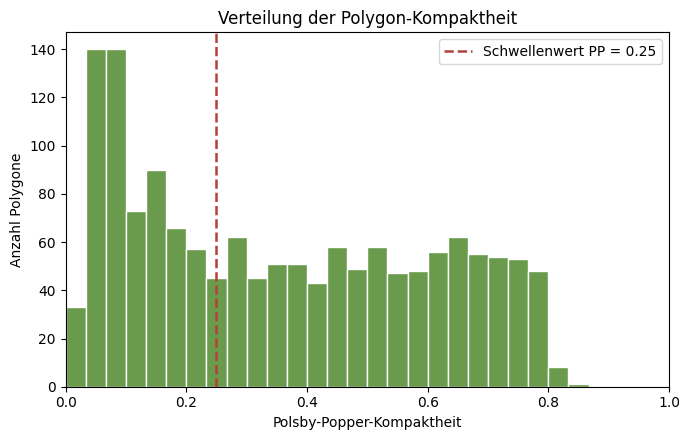

In [ ]:
def pp_compactness(geom):
    """Polsby-Popper compactness index."""
    if geom is None or geom.is_empty:
        return None
    p = geom.length
    a = geom.area
    if p == 0:
        return None
    return (4 * pi * a) / (p * p)

gdf = gpd.read_file(input_fp)
print(f"Original feature count: {len(gdf)}")

gdf = gdf[gdf[code_column] == target_code].copy()
print(f"Code feature count: {len(gdf)}")

gdf['compactness'] = gdf.geometry.apply(pp_compactness)
gdf['area_m2']     = gdf.geometry.area

# --- Histogramm ---
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(gdf['compactness'].dropna(), bins=30, range=(0, 1),
        color="#6a9a4b", edgecolor="white")
ax.axvline(compactness_threshold, color="#b5403a", linestyle="--", linewidth=1.8,
           label=f"Schwellenwert PP = {compactness_threshold}")
ax.set_xlabel("Polsby-Popper-Kompaktheit")
ax.set_ylabel("Anzahl Polygone")
ax.set_title("Verteilung der Polygon-Kompaktheit")
ax.legend()
ax.set_xlim(0, 1)
fig.tight_layout()
fig.savefig("pp_distribution.png", dpi=200)
plt.show()

Polygons in the area [0.24, 0.26]: 8


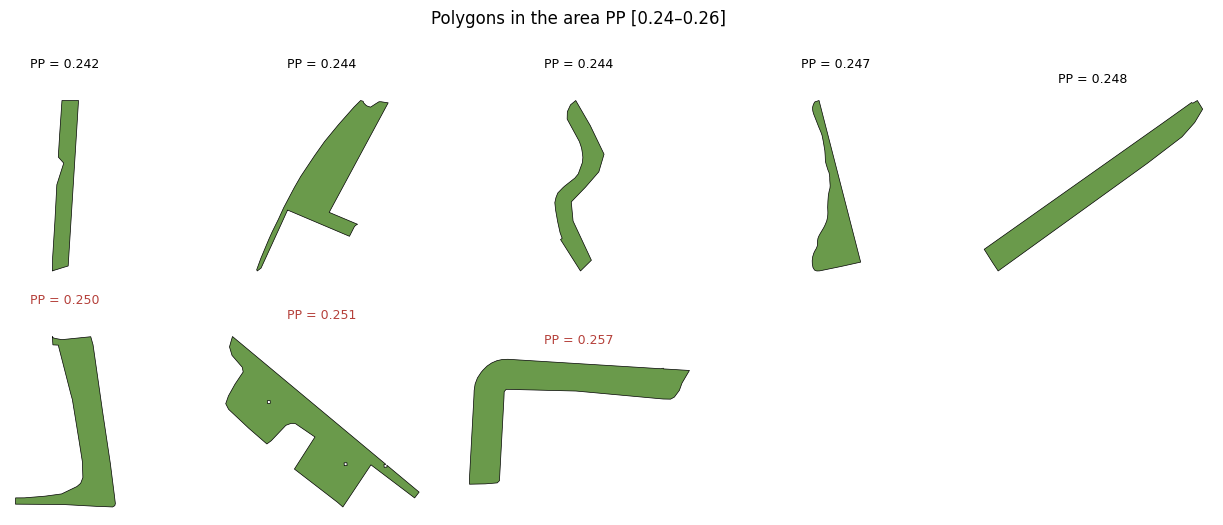

In [21]:
# Narrow down the range
lower, upper = 0.24, 0.26

borderline = gdf[
    (gdf['compactness'] >= lower) & (gdf['compactness'] <= upper)
].sort_values('compactness').copy()

print(f"Polygons in the area [{lower}, {upper}]: {len(borderline)}")

# A grid of subplots, with one polygon per cell
n = len(borderline)
ncols = 5
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.6, nrows * 2.6))
axes = axes.flatten()

for ax, (_, row) in zip(axes, borderline.iterrows()):
    gpd.GeoSeries([row.geometry]).plot(ax=ax, color="#6a9a4b", edgecolor="black", linewidth=0.5)
    pp = row['compactness']
    # Mark the threshold with a colour
    color = "#b5403a" if pp >= compactness_threshold else "black"
    ax.set_title(f"PP = {pp:.3f}", fontsize=9, color=color)
    ax.set_aspect('equal')
    ax.axis('off')

# hide empty cells
for ax in axes[n:]:
    ax.axis('off')

fig.suptitle(f"Polygons in the area PP [{lower}–{upper}]", y=1.0)
fig.tight_layout()
fig.savefig("pp_borderline_polygons.png", dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
output_linear_fp = '...'

gdf_linear = gdf[gdf['compactness'] < compactness_threshold].copy()

print(f"Linear features (< {compactness_threshold}): {len(gdf_linear)}")
print(f"Total area before filtering: {gdf['area_m2'].sum() / 10000:.2f} ha")
print(f"Total area after filtering:  {gdf_linear['area_m2'].sum() / 10000:.2f} ha")

gdf_linear.to_file(output_linear_fp, driver='GPKG')
print(f"Saved to: {output_linear_fp}")

## 2. Produce fused Polygon-Flowerstrip Layer

In [ ]:
merge_fps = [
    ('.../NRW/NRW_strips90_25_linear.gpkg', None),
    ('.../NRW/NRW_strips590_25_linear.gpkg', None),
    ('.../NRW/NRW_strips871_25_linear.gpkg', None),
    ('.../NRW/NRW_strips910_25_linear.gpkg', None),
    ('.../NRW/NRW_strips918_25_linear.gpkg', None),
    ('.../NRW/NRW_strips92_25.gpkg', None)
]
merged_fp = '.../flowerstrips_NRW_mergedALL.gpkg'

layers = []
for fp, layer in merge_fps:
    gdf = gpd.read_file(fp, layer=layer) if layer else gpd.read_file(fp)
    layers.append(gdf)
    print(f"  {os.path.basename(fp)}: {len(gdf)} features")

merged = gpd.GeoDataFrame(pd.concat(layers, ignore_index=True), crs=target_crs)
print(f"\nTotal features after merge: {len(merged)}")

merged.to_file(merged_fp, driver='GPKG')
print(f"Saved to {merged_fp}")

## 3. Overlay-Trees
The .tif tree overlays are sourced from Siyu Liu et al. ,The overlooked contribution of trees outside forests to tree cover and woody biomass across Europe.Sci. Adv.9,eadh4097(2023).DOI:10.1126/sciadv.adh4097.
At the authors' suggestion, a 5 m threshold was implemented. This code will polygonise the raster data and check whether they are in the project coordinate reference system (CRS). Then, they will be overlaid with the final label layer.

In [ ]:
# Paths
tree_raster_path   = '.../trees_BB_5mThreshold.tif'      # dein neuer 0/1 Raster
output_tree_poly   = '.../trees_BB5mThreshold_polygons_mergedALL.gpkg'
merged_fp          = '.../BB/flowerstrips_BB_mergedALL.gpkg'
overlay_fp         = '.../overlaytrees/flowerstrips_overlayBB_mergedALL.gpkg'
N_WORKERS          = 8
CHUNK_SIZE         = 300

# ── Step 1: Raster → Polygon (chunked) ───────────────────────────────────────

print("Polygonizing tree raster (chunked)...")

chunk_size_rows = 4096
all_geoms, all_vals = [], []

with rasterio.open(tree_raster_path) as src:
    crs = src.crs
    height = src.height

    for row_off in range(0, height, chunk_size_rows):
        actual_height = min(chunk_size_rows, height - row_off)
        window = rasterio.windows.Window(0, row_off, src.width, actual_height)
        data = src.read(1, window=window).astype("uint8")
        win_transform = src.window_transform(window)
        mask = data == 1
        if not mask.any():
            continue
        for geom, val in shapes(data, mask=mask, transform=win_transform):
            if val == 1:
                all_geoms.append(shape(geom))
                all_vals.append(int(val))
        print(f"  Rows {row_off}–{row_off + actual_height} / {height}")

gdf_trees = gpd.GeoDataFrame({"value": all_vals}, geometry=all_geoms, crs=crs)
print(f"  Tree polygons: {len(gdf_trees):,}")

gdf_trees.to_file(output_tree_poly, driver="GPKG", layer="trees")
print(f"  Saved: {output_tree_poly}")

# ── CRS Check ────────────────────────────────────────────────────────────────
flower_check = gpd.read_file(merged_fp)
gdf_trees_check = gpd.read_file(output_tree_poly, layer="trees")

print(f"Flowerstrips CRS : {flower_check.crs}")
print(f"Trees CRS        : {gdf_trees_check.crs}")

assert flower_check.crs.to_epsg() == 3035, "ERROR: Flowerstrips ist nicht EPSG:3035!"
assert gdf_trees_check.crs.to_epsg() == 3035, "ERROR: Trees ist nicht EPSG:3035!"

print("✓ Both Layers are EPSG:3035 (LAEA)")

# ── Step 2: Overlay (dein bewährter Multiprocessing-Code, nur tree_fp angepasst) ──

# ALT: tree_fp = '.../Trees12-25_BB.gpkg'
tree_fp = output_tree_poly  # <── jetzt der polygonisierte Raster

def init_worker(tree_path, crs):
    global trees
    trees = gpd.read_file(tree_path).to_crs(crs)
    trees.sindex

def process_chunk(chunk):
    global trees
    minx, miny, maxx, maxy = chunk.total_bounds
    possible_idx = list(trees.sindex.intersection((minx, miny, maxx, maxy)))
    if possible_idx:
        return gpd.overlay(chunk, trees.iloc[possible_idx], how='difference')
    return chunk.copy()

flower = gpd.read_file(merged_fp)
chunks = [flower.iloc[i:i+CHUNK_SIZE].copy() for i in range(0, len(flower), CHUNK_SIZE)]

with Pool(processes=N_WORKERS, initializer=init_worker, initargs=(tree_fp, flower.crs)) as pool:
    results = list(tqdm(pool.imap(process_chunk, chunks), total=len(chunks), desc="Overlay progress"))

overlay = gpd.GeoDataFrame(pd.concat(results, ignore_index=True), crs=flower.crs)
overlay.to_file(overlay_fp, driver='GPKG')
print(f"Saved to {overlay_fp}")

## 4. Remove small Polygons
**Breakdown into individual parts and area filtering:** The multipart geometries from the tree overlay are broken down into individual polygons (`explode`), as an original strip may have been split into several separate sections following intersection with the tree areas. Polygons smaller than 125 m² are then removed to eliminate artefacts and excessively small residual areas, and each remaining polygon is assigned a unique `polygon_id`.

In [ ]:
# Paths
overlay_fp  = '.../overlaytrees/flowerstrips_overlayNRW.gpkg'
filtered_fp = '.../NRW/flowerstrips_filtered_NRW.gpkg'
min_area_m2 = 125

overlay = gpd.read_file(overlay_fp)

singlepart = overlay.explode(index_parts=False).reset_index(drop=True)
print(f"Features after explode (singlepart): {len(singlepart)}")

singlepart['area_m2'] = singlepart.geometry.area
filtered = singlepart[singlepart['area_m2'] >= min_area_m2].reset_index(drop=True)
print(f"Features after area filter (>= {min_area_m2} m²): {len(filtered)}")

filtered['polygon_id'] = range(1, len(filtered) + 1)

filtered.to_file(filtered_fp, driver='GPKG')
print(f"Saved to {filtered_fp}")

## 5. Core-buffer filter (Level 2 → Level 3):
A negative buffer of 1.5 m is applied to identify and remove very narrow polygons that collapse to zero area when eroded — these are too thin to represent reliable flower strips at the given resolution. The buffer is used only for identification; the surviving polygons retain their original (unbuffered) geometries, matched back via `polygon_id`.


In [ ]:
# ── Paths ────────────────────────────────────────────────────────────────────
filtered_fp        = '.../NRW/flowerstrips_filtered_NRW.gpkg'
corebuffer_fp      = '.../NRW/flowerstrips_L3_NRW.gpkg' # Level 3 PreProcessing
buffered_check_fp  = '.../NRW/flowerstrips_buffered_check_NRW.gpkg'
BUFFER_DIST        = -1.5  # Meter
MIN_AREA_M2        = 0     # Polygone die nach Puffer <= 0m² sind werden ausgeschlossen

# ── Core-Buffer Filter (Level 2 → Level 3) ───────────────────────────────────
import geopandas as gpd

print("Loading filtered layer...")
gdf = gpd.read_file(filtered_fp)
print(f"  Polygons before filter: {len(gdf):,}")

# Negativen Puffer berechnen — nur zur Identifikation
print(f"Applying {BUFFER_DIST}m buffer...")
gdf_buffered = gdf.copy()
gdf_buffered['geometry'] = gdf.geometry.buffer(BUFFER_DIST)
gdf_buffered['area_buffered_m2'] = gdf_buffered.geometry.area

# Zwischenlayer speichern zur Kontrolle in QGIS
gdf_buffered.to_file(buffered_check_fp, driver='GPKG')
print(f"  Buffered check layer saved: {buffered_check_fp}")

# IDs der Polygone die nach Puffer verschwinden (Fläche <= 0)
ids_to_remove = gdf_buffered[gdf_buffered['area_buffered_m2'] <= MIN_AREA_M2]['polygon_id']
print(f"  Polygons removed (disappeared after buffer): {len(ids_to_remove):,}")

# Originallayer filtern — Originalgeometrien behalten!
gdf_L3 = gdf[~gdf['polygon_id'].isin(ids_to_remove)].reset_index(drop=True)
print(f"  Polygons after filter (L3): {len(gdf_L3):,}")

# Speichern
gdf_L3.to_file(corebuffer_fp, driver='GPKG')
print(f"Saved to {corebuffer_fp}")

## 6. Clip Chips
**Rasterizing label chips:** This script generates 592×592 label chips from the cleaned flower-strip polygons (Level 3). Each template chip defines a target extent and pixel grid; the polygons intersecting that extent are clipped and rasterized to a binary mask (1 = flower strip, 0 = background), then written as a GeoTIFF aligned to the corresponding satellite chip. Chips already present in the output folder are skipped — clear `OUT_DIR` before re-running with changed input data.

And

**Subsetting labels to valid SR chips:** This step reduces the full set of label chips to only those that have a matching super-resolved Sentinel-2 chip (using April as the reference month, since chip IDs are identical across months). Label chips whose filename matches a valid SR chip are copied to the `filtered` folder; the rest are discarded. Matching relies on identical filenames in both folders — verify the naming convention aligns before running.

Das Skript nutzt vom rohen Template-Chip nur zwei Dinge:

Den Mittelpunkt (cx, cy) – die ursprüngliche Größe (592 vs. 608 etc.) wird komplett ignoriert und verworfen
Die Auflösung (die eh immer 2.5m ist)

Danach wird um diesen Mittelpunkt ein komplett neues, fest 592×592 großes Fenster zentriert und die Polygone frisch draufgerastert. Die variable Größe der Rohvorlagen ist also für das Endergebnis irrelevant – sie diente offenbar nur dazu, überhaupt einen Mittelpunkt pro Parzelle/Chip zu haben.

In [ ]:
# set the path to the polygon data, to the template chips, and to the output folder
POLYGON_FILE = ".../NRW/flowerstrips_L3_NRWPolspy.gpkg"
CHIPS_DIR = ".../nrw_template_chips_3035"
OUT_DIR = ".../labels/chips_total_NRW"
TARGET_SIZE = 592  # output must be 592 x 592
N_PROCESSES = 10   # adjust to your server

os.makedirs(OUT_DIR, exist_ok=True)

# list all the chips used as cookie-cutter
chip_files = sorted(glob(os.path.join(CHIPS_DIR, "*.tif"))) # [:200] # limit to 200 for testing, remove [:200] for full run

# load polygon data once
gdf = gpd.read_file(POLYGON_FILE)
gdf = gdf.to_crs(target_crs)  # make sure polygons are in the same CRS as the template chips


def process_chip(chip_fp):
    out_name = os.path.splitext(os.path.basename(chip_fp))[0] + "_vrt_clip.tif"
    out_fp = os.path.join(OUT_DIR, out_name)

    if os.path.exists(out_fp):
        return out_name

    with rasterio.open(chip_fp) as chip:
        # derive pixel size from chip and center the square on chip extent
        xmin, ymin, xmax, ymax = chip.bounds
        resx = abs(chip.transform.a)
        resy = abs(chip.transform.e)
        res = (resx + resy) / 2.0
        cx = (xmin + xmax) / 2.0
        cy = (ymin + ymax) / 2.0
        half = (TARGET_SIZE * res) / 2.0
        new_xmin, new_xmax = cx - half, cx + half
        new_ymin, new_ymax = cy - half, cy + half

        dst_transform = from_bounds(
            new_xmin, new_ymin, new_xmax, new_ymax, TARGET_SIZE, TARGET_SIZE
        )

        # clip polygon data to the target chip extent
        chip_bbox = box(new_xmin, new_ymin, new_xmax, new_ymax)
        gdf_chip = gdf[gdf.intersects(chip_bbox)].copy()

        if not gdf_chip.empty:
            gdf_chip = gdf_chip.clip(chip_bbox)

            # rasterize polygons directly to the final chip grid
            shapes = [(geom, 1) for geom in gdf_chip.geometry if geom is not None and not geom.is_empty]

            dst_arr = rasterize(
                shapes=shapes,
                out_shape=(TARGET_SIZE, TARGET_SIZE),
                transform=dst_transform,
                fill=0,
                dtype="uint8"
            )
        else:
            # empty chip if no flowerstrips intersect this extent
            dst_arr = np.zeros((TARGET_SIZE, TARGET_SIZE), dtype="uint8")

        # write output
        out_profile = chip.profile.copy()
        out_profile.update({
            "height": TARGET_SIZE,
            "width": TARGET_SIZE,
            "transform": dst_transform,
            "crs": chip.crs,
            "count": 1,
            "dtype": "uint8",
            "compress": "DEFLATE",
            "nodata": 0,
        })

        with rasterio.open(out_fp, "w", **out_profile) as dst:
            dst.write(dst_arr, 1)

    return out_name


if __name__ == "__main__":
    with Pool(N_PROCESSES) as pool:
        pool.map(process_chip, chip_files)

    print("Done. Outputs in:", OUT_DIR)

In [ ]:
## Die Chips aussortieren die nicht in BB/NRW liegen und wo die SR-Chips leer sind! In diesem Part wird der Pfad der SR-Daten genutzt der gefiltert wurde hier april dieser Pfad wurde mithilfe von Satellite-Chip-Preparation erstellt
# ── CONFIG ────────────────────────────────────────────────────────────────────
sr_filtered_dir    = Path('...')  # nur einen Monat nötig für die IDs
label_src_dir      = Path('...')
label_dst_dir      = Path('...')
# ─────────────────────────────────────────────────────────────────────────────

label_dst_dir.mkdir(parents=True, exist_ok=True)

# get valid chip IDs from SR filtered folder (april as reference)
sr_ids = {f.name for f in sr_filtered_dir.glob('*.tif')}
print(f"Valid SR chips (reference): {len(sr_ids)}")

# match and copy label chips
copied = 0
not_found = 0
for sr_name in sr_ids:
    label_src = label_src_dir / sr_name
    if label_src.exists():
        shutil.copy2(str(label_src), str(label_dst_dir / sr_name))
        copied += 1
    else:
        not_found += 1

print(f"Label chips copied: {copied}")
print(f"Label chips not found: {not_found}")
print(f"Done. Saved to: {label_dst_dir}")